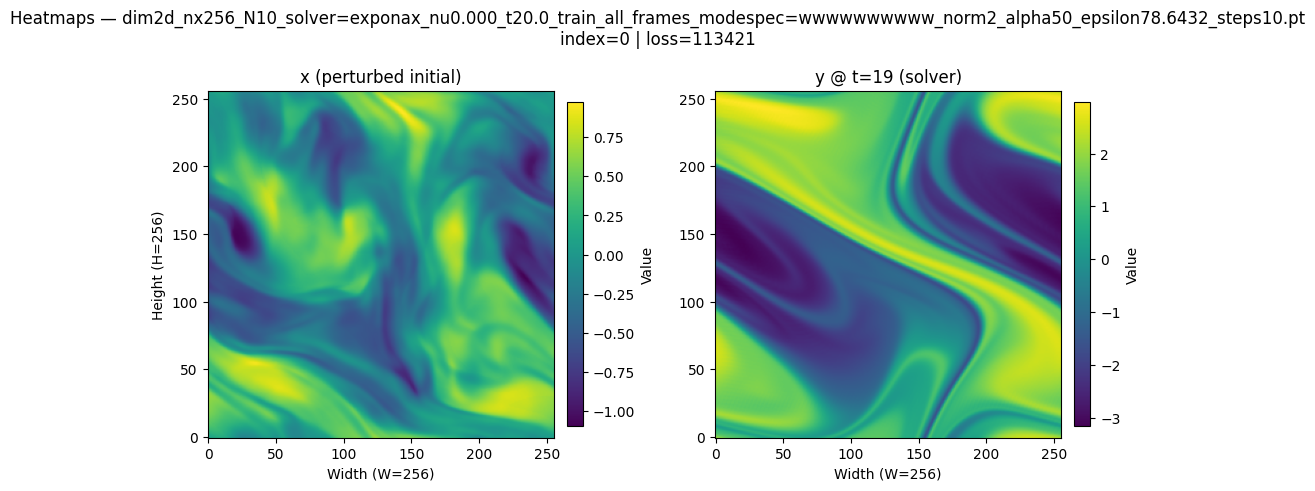

In [ ]:
# Minimal heatmap for a saved .pt dataset (English labels + loss in title)
from pathlib import Path
import torch
import numpy as np
import matplotlib.pyplot as plt

# ---- user params ----
pt_path = Path("dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_train_all_frames_modespec=wwwwwwwwww_norm2_alpha50_epsilon78.6432_steps10.pt")
index   = 0      # which sample to plot
t       = 19     # which time slice from y (0..20)
save_to = None   # e.g., Path("heatmap.png"); None -> just show

# ---- load ----
data = torch.load(pt_path, map_location="cpu")
x = data["x"]                # (N,H,W)
y = data["y"]                # (N,H,W,21)
loss = data.get("loss", None)

N, H, W = x.shape
assert 0 <= index < N, f"index out of range 0..{N-1}"
assert 0 <= t <= 20, "t must be in [0, 20]"


xi = x[index].numpy()            # (H,W)
yi = y[index, :, :, t].numpy()   # (H,W) at time t

# ---- figure ----
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cmap = "viridis"  # fixed as requested

im0 = axes[0].imshow(xi, origin="lower", cmap=cmap)
axes[0].set_title("x (perturbed initial)")
axes[0].set_xlabel(f"Width (W={W})")
axes[0].set_ylabel(f"Height (H={H})")
cbar0 = fig.colorbar(im0, ax=axes[0], shrink=0.9, pad=0.03)
cbar0.set_label("Value")

im1 = axes[1].imshow(yi, origin="lower", cmap=cmap)
axes[1].set_title(f"y @ t={t} (solver)")
axes[1].set_xlabel(f"Width (W={W})")
axes[1].set_ylabel("")
cbar1 = fig.colorbar(im1, ax=axes[1], shrink=0.9, pad=0.03)
cbar1.set_label("Value")

# Big English suptitle with loss; extra space to avoid overlap
fname = pt_path.name
if loss is not None:
    lval = float(loss[index])
    suptitle = f"Heatmaps — {fname}\nindex={index} | loss={lval:.6g}"
else:
    suptitle = f"Heatmaps — {fname}\nindex={index}"
fig.suptitle(suptitle, y=0.98)
plt.subplots_adjust(top=0.83)  # leave generous space for multi-line title

if save_to:
    plt.savefig(save_to, dpi=150, bbox_inches="tight")
    print(f"Saved: {save_to}")
else:
    plt.show()




In [6]:
from pathlib import Path
import torch
import numpy as np

def summarize_pt(path):
    path = Path(path)
    data = torch.load(path, map_location="cpu")
    print(f"[File] {path}")
    print(f"[Keys] {list(data.keys())}\n")

    def tensor_info(t: torch.Tensor):
        size_mb = t.element_size() * t.numel() / 1024**2
        msg = (f"Tensor | shape={tuple(t.shape)}, dtype={t.dtype}, device={t.device}, "
               f"numel={t.numel():,}, size≈{size_mb:.2f} MB")
        try:
            mn, mx, mean = t.min().item(), t.max().item(), t.mean().item()
            msg += f", min={mn:.6g}, max={mx:.6g}, mean={mean:.6g}"
        except Exception:
            pass
        return msg

    for k, v in data.items():
        if torch.is_tensor(v):
            info = tensor_info(v)
        elif isinstance(v, np.ndarray):
            info = f"ndarray | shape={v.shape}, dtype={v.dtype}"
        elif isinstance(v, (list, tuple)):
            info = f"{type(v).__name__} | len={len(v)}"
            if len(v) > 0:
                info += f", first_elem_type={type(v[0]).__name__}"
        elif isinstance(v, dict):
            info = f"dict | {len(v)} keys"
        else:
            info = f"{type(v).__name__}"
        print(f"- {k}: {info}")

    # 额外一致性检查（按你的数据格式约定）
    x = data.get("x", None)
    y = data.get("y", None)
    if torch.is_tensor(x):
        N, H, W = x.shape
        print(f"\n[Derived] N={N}, H={H}, W={W}")
    if torch.is_tensor(y) and y.ndim == 4:
        print(f"[Derived] y time-frames = {y.shape[-1]}")
        if torch.is_tensor(x) and (y.shape[:3] != x.shape):
            print("[Warn] x.shape != y.shape[:3]")

# 示例：
summarize_pt("dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_train_all_frames_modespec=wwwwwwwwww_norm2_alpha1_epsilon13.1072_steps10.pt")


[File] dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_train_all_frames_modespec=wwwwwwwwww_norm2_alpha1_epsilon13.1072_steps10.pt
[Keys] ['x', 'y', 'loss']

- x: Tensor | shape=(10, 256, 256), dtype=torch.float32, device=cpu, numel=655,360, size≈2.50 MB, min=-0.805753, max=0.793357, mean=0.000310408
- y: Tensor | shape=(10, 256, 256, 21), dtype=torch.float32, device=cpu, numel=13,762,560, size≈52.50 MB, min=-3.46315, max=3.33379, mean=0.000310404
- loss: Tensor | shape=(10,), dtype=torch.float32, device=cpu, numel=10, size≈0.00 MB, min=5502.61, max=35954.5, mean=13822.7

[Derived] N=10, H=256, W=256
[Derived] y time-frames = 21


In [1]:
# Minimal heatmap for all .pt datasets in current folder (English labels + loss in title)
from pathlib import Path
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# ---- user params ----
t       = 19     # which time slice from y (0..T-1)
root    = Path.cwd()   # 当前 ipynb 所在目录
out_dir = root / "heatmaps"
cmap    = "viridis"  # fixed as requested

def load_xy_loss(pt_path: Path):
    """Load a .pt file and return (x, y, loss or None)."""
    data = torch.load(pt_path, map_location="cpu")
    x = data.get("x", None)
    y = data.get("y", None)
    if x is None or y is None:
        # fallback: 尝试从任意 tensor 字段里推断
        for k, v in data.items():
            if isinstance(v, torch.Tensor):
                if y is None and v.dim() == 4:
                    y = v
                elif x is None and v.dim() == 3:
                    x = v
    if x is None or y is None:
        raise ValueError(f"{pt_path.name}: cannot find 'x' (N,H,W) and 'y' (N,H,W,T) tensors")
    return x, y, data.get("loss", None)

def plot_one(xi: np.ndarray, yi: np.ndarray, H: int, W: int, pt_name: str, idx1: int, t: int, loss_val):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    im0 = axes[0].imshow(xi, origin="lower", cmap=cmap)
    axes[0].set_title("x (perturbed initial)")
    axes[0].set_xlabel(f"Width (W={W})")
    axes[0].set_ylabel(f"Height (H={H})")
    cbar0 = fig.colorbar(im0, ax=axes[0], shrink=0.9, pad=0.03)
    cbar0.set_label("Value")

    im1 = axes[1].imshow(yi, origin="lower", cmap=cmap)
    axes[1].set_title(f"y @ t={t} (solver)")
    axes[1].set_xlabel(f"Width (W={W})")
    axes[1].set_ylabel("")
    cbar1 = fig.colorbar(im1, ax=axes[1], shrink=0.9, pad=0.03)
    cbar1.set_label("Value")

    # 英文大标题，包含 loss（若存在）
    if loss_val is not None:
        suptitle = f"Heatmaps — {pt_name}\nindex={idx1} | loss={float(loss_val):.6g}"
    else:
        suptitle = f"Heatmaps — {pt_name}\nindex={idx1}"
    fig.suptitle(suptitle, y=0.98)
    plt.subplots_adjust(top=0.83)

    return fig

def main():
    out_dir.mkdir(parents=True, exist_ok=True)
    pt_files = sorted(root.glob("*.pt"))

    if not pt_files:
        print("[WARN] No .pt files found in", root)
        return

    for pt_path in pt_files:
        try:
            x, y, loss = load_xy_loss(pt_path)
        except Exception as e:
            print(f"[SKIP] {pt_path.name}: {e}")
            continue

        # 形状检查
        if x.dim() != 3 or y.dim() != 4:
            print(f"[SKIP] {pt_path.name}: unexpected shapes x={tuple(x.shape)}, y={tuple(y.shape)}")
            continue

        N, H, W = x.shape
        T_total = y.shape[-1]
        if t < 0 or t >= T_total:
            print(f"[SKIP] {pt_path.name}: t={t} out of range [0..{T_total-1}]")
            continue

        # 每个 .pt 的输出子目录
        sub_out = out_dir / pt_path.stem
        sub_out.mkdir(parents=True, exist_ok=True)

        print(f"[INFO] {pt_path.name} | N={N}, H={H}, W={W}, T={T_total} → saving to {sub_out}")

        # 循环 1..N（1-based），内部转成 0-based 索引
        for idx1 in tqdm(range(1, N+1), desc=f"Plotting {pt_path.name}", leave=False):
            idx0 = idx1 - 1
            xi = x[idx0].numpy()            # (H,W)
            yi = y[idx0, :, :, t].numpy()   # (H,W) at time t

            loss_val = None
            if loss is not None:
                # loss 可能是标量/张量；尽量取对应样本的
                try:
                    loss_val = float(loss[idx0])
                except Exception:
                    try:
                        loss_val = float(loss)
                    except Exception:
                        loss_val = None

            fig = plot_one(xi, yi, H, W, pt_path.name, idx1, t, loss_val)

            save_path = sub_out / f"index_{idx1}_t_{t}.png"
            fig.savefig(save_path, dpi=150, bbox_inches="tight")
            plt.close(fig)

        print(f"[DONE] {pt_path.name}")

if __name__ == "__main__":
    main()


[INFO] dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_train_all_frames_modespec=wwwwwwwwww_norm2_alpha10_epsilon13.1072_steps10.pt | N=10, H=256, W=256, T=21 → saving to /blue/shiboli.fsu/yifeisun.umich/adversarial_robustness_FNO/2D_NS_FNO2d_recurrent/datasets/expanded_exponax_datasets/t20/N=10/heatmaps/dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_train_all_frames_modespec=wwwwwwwwww_norm2_alpha10_epsilon13.1072_steps10


[DONE] dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_train_all_frames_modespec=wwwwwwwwww_norm2_alpha10_epsilon13.1072_steps10.pt
[INFO] dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_train_all_frames_modespec=wwwwwwwwww_norm2_alpha10_epsilon39.3216_steps10.pt | N=10, H=256, W=256, T=21 → saving to /blue/shiboli.fsu/yifeisun.umich/adversarial_robustness_FNO/2D_NS_FNO2d_recurrent/datasets/expanded_exponax_datasets/t20/N=10/heatmaps/dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_train_all_frames_modespec=wwwwwwwwww_norm2_alpha10_epsilon39.3216_steps10


[DONE] dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_train_all_frames_modespec=wwwwwwwwww_norm2_alpha10_epsilon39.3216_steps10.pt
[INFO] dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_train_all_frames_modespec=wwwwwwwwww_norm2_alpha10_epsilon78.6432_steps10.pt | N=10, H=256, W=256, T=21 → saving to /blue/shiboli.fsu/yifeisun.umich/adversarial_robustness_FNO/2D_NS_FNO2d_recurrent/datasets/expanded_exponax_datasets/t20/N=10/heatmaps/dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_train_all_frames_modespec=wwwwwwwwww_norm2_alpha10_epsilon78.6432_steps10


[DONE] dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_train_all_frames_modespec=wwwwwwwwww_norm2_alpha10_epsilon78.6432_steps10.pt
[INFO] dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_train_all_frames_modespec=wwwwwwwwww_norm2_alpha1_epsilon13.1072_steps10.pt | N=10, H=256, W=256, T=21 → saving to /blue/shiboli.fsu/yifeisun.umich/adversarial_robustness_FNO/2D_NS_FNO2d_recurrent/datasets/expanded_exponax_datasets/t20/N=10/heatmaps/dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_train_all_frames_modespec=wwwwwwwwww_norm2_alpha1_epsilon13.1072_steps10


[DONE] dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_train_all_frames_modespec=wwwwwwwwww_norm2_alpha1_epsilon13.1072_steps10.pt
[INFO] dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_train_all_frames_modespec=wwwwwwwwww_norm2_alpha1_epsilon39.3216_steps10.pt | N=10, H=256, W=256, T=21 → saving to /blue/shiboli.fsu/yifeisun.umich/adversarial_robustness_FNO/2D_NS_FNO2d_recurrent/datasets/expanded_exponax_datasets/t20/N=10/heatmaps/dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_train_all_frames_modespec=wwwwwwwwww_norm2_alpha1_epsilon39.3216_steps10


...

[DONE] dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_train_all_frames_modespec=wwwwwwwwww_norm2_alpha50_epsilon39.3216_steps10.pt
[INFO] dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_train_all_frames_modespec=wwwwwwwwww_norm2_alpha50_epsilon78.6432_steps10.pt | N=10, H=256, W=256, T=21 → saving to /blue/shiboli.fsu/yifeisun.umich/adversarial_robustness_FNO/2D_NS_FNO2d_recurrent/datasets/expanded_exponax_datasets/t20/N=10/heatmaps/dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_train_all_frames_modespec=wwwwwwwwww_norm2_alpha50_epsilon78.6432_steps10


[DONE] dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_train_all_frames_modespec=wwwwwwwwww_norm2_alpha50_epsilon78.6432_steps10.pt
[INFO] dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_train_all_frames_modespec=wwwwwwwwww_norm2_alpha5_epsilon13.1072_steps10.pt | N=10, H=256, W=256, T=21 → saving to /blue/shiboli.fsu/yifeisun.umich/adversarial_robustness_FNO/2D_NS_FNO2d_recurrent/datasets/expanded_exponax_datasets/t20/N=10/heatmaps/dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_train_all_frames_modespec=wwwwwwwwww_norm2_alpha5_epsilon13.1072_steps10


[DONE] dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_train_all_frames_modespec=wwwwwwwwww_norm2_alpha5_epsilon13.1072_steps10.pt
[INFO] dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_train_all_frames_modespec=wwwwwwwwww_norm2_alpha5_epsilon39.3216_steps10.pt | N=10, H=256, W=256, T=21 → saving to /blue/shiboli.fsu/yifeisun.umich/adversarial_robustness_FNO/2D_NS_FNO2d_recurrent/datasets/expanded_exponax_datasets/t20/N=10/heatmaps/dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_train_all_frames_modespec=wwwwwwwwww_norm2_alpha5_epsilon39.3216_steps10


[DONE] dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_train_all_frames_modespec=wwwwwwwwww_norm2_alpha5_epsilon39.3216_steps10.pt
[INFO] dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_train_all_frames_modespec=wwwwwwwwww_norm2_alpha5_epsilon78.6432_steps10.pt | N=10, H=256, W=256, T=21 → saving to /blue/shiboli.fsu/yifeisun.umich/adversarial_robustness_FNO/2D_NS_FNO2d_recurrent/datasets/expanded_exponax_datasets/t20/N=10/heatmaps/dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_train_all_frames_modespec=wwwwwwwwww_norm2_alpha5_epsilon78.6432_steps10


[DONE] dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_train_all_frames_modespec=wwwwwwwwww_norm2_alpha5_epsilon78.6432_steps10.pt
